# Telco Customer Churn Analysis

This notebook investigates customer churn through reproducible cleaning and analysis. All findings are associations and should not be interpreted as causal effects.

## Clean

**Goal.** Load the customer data, detect missing or incorrectly typed values, make defensible cleaning decisions, and verify the result. The original row count is recorded before any changes, and a fixed seed is defined for reproducibility in later analysis.

In [1]:
import pandas as pd

RANDOM_SEED = 42
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv.xls"

df = pd.read_csv(DATA_PATH)
original_rows = len(df)
print(f"Loaded {original_rows:,} rows and {df.shape[1]} columns.")

Loaded 7,043 rows and 21 columns.


### Initial inspection

Standard null checks do not detect strings containing only whitespace, so text columns are also checked after trimming whitespace. This inspection shows that `TotalCharges` was loaded as text and contains 11 blank values.

In [2]:
text_columns = df.select_dtypes(include="object")
blank_counts = text_columns.apply(lambda column: column.str.strip().eq("").sum())

display(df.head())
display(df.dtypes.rename("dtype"))
display(blank_counts[blank_counts.gt(0)].rename("blank_values"))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
Name: dtype, dtype: object

TotalCharges    11
Name: blank_values, dtype: int64

### Convert numeric text and handle missing charges

A reusable function examines every text column and converts it only when all its nonblank values are numeric. The 11 missing `TotalCharges` values all belong to customers with `tenure == 0`, so they represent new customers who have not accumulated charges. An assertion checks that explanation before the values are filled with 0.

In [3]:
def convert_numeric_text_columns(data):
    cleaned = data.copy()
    for column in cleaned.select_dtypes(include="object"):
        stripped = cleaned[column].str.strip()
        nonblank = stripped.ne("")
        converted = pd.to_numeric(stripped, errors="coerce")
        if nonblank.any() and converted[nonblank].notna().all():
            cleaned[column] = converted
    return cleaned

df = convert_numeric_text_columns(df)
missing_total_charges = df["TotalCharges"].isna()
assert df.loc[missing_total_charges, "tenure"].eq(0).all()
print(f"Zero-tenure customers with missing TotalCharges: {missing_total_charges.sum()}")
df.loc[missing_total_charges, "TotalCharges"] = 0

Zero-tenure customers with missing TotalCharges: 11


### Remove the identifier and preserve service status

`customerID` is unique for every row and does not describe customer behaviour, so it is removed. `No internet service` and `No phone service` remain distinct categories because lacking a service differs from having the service and declining an add-on.

In [4]:
assert df["customerID"].nunique() == len(df)
no_internet_columns = df.columns[df.eq("No internet service").any()].tolist()
no_phone_columns = df.columns[df.eq("No phone service").any()].tolist()
df = df.drop(columns="customerID")

print("No internet service columns:", no_internet_columns)
print("No phone service columns:", no_phone_columns)

No internet service columns: ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
No phone service columns: ['MultipleLines']


### Clean-data validation

The final checks confirm that no rows were lost, no missing values remain, `TotalCharges` is numeric, and the target still uses clear `Yes`/`No` labels.

In [5]:
churn_rate = df["Churn"].eq("Yes").mean()
assert len(df) == original_rows
assert df.isna().sum().sum() == 0
assert pd.api.types.is_numeric_dtype(df["TotalCharges"])
assert set(df["Churn"].unique()) == {"Yes", "No"}

print(f"Rows: {original_rows:,} before, {len(df):,} after")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Churn rate: {churn_rate:.2%}")
display(df.dtypes.rename("dtype"))

Rows: 7,043 before, 7,043 after
Missing values: 0
Churn rate: 26.54%


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
Name: dtype, dtype: object

## EDA

First, we look for patterns in the data. The bar charts show the share of customers who churned in each category. The two box plots show how tenure and monthly charges differ between customers who stayed and customers who left. These charts describe what happened; they do not show why it happened.

### Contract type

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: churn_rate_pct, dtype: float64

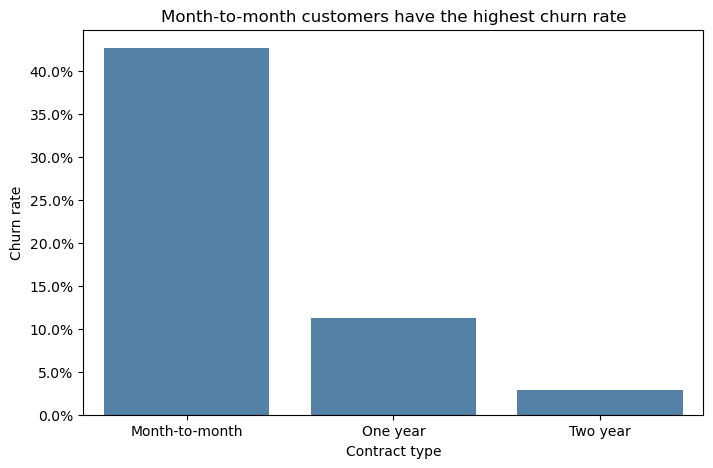

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

contract_churn = df.groupby("Contract")["Churn"].apply(lambda values: values.eq("Yes").mean())
display((contract_churn * 100).round(2).rename("churn_rate_pct"))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn.values, color="steelblue", ax=ax)
ax.set(title="Month-to-month customers have the highest churn rate", xlabel="Contract type", ylabel="Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

**What we see:** 42.71% of month-to-month customers churned, compared with 11.27% on one-year contracts and 2.83% on two-year contracts.

### Internet service

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: churn_rate_pct, dtype: float64

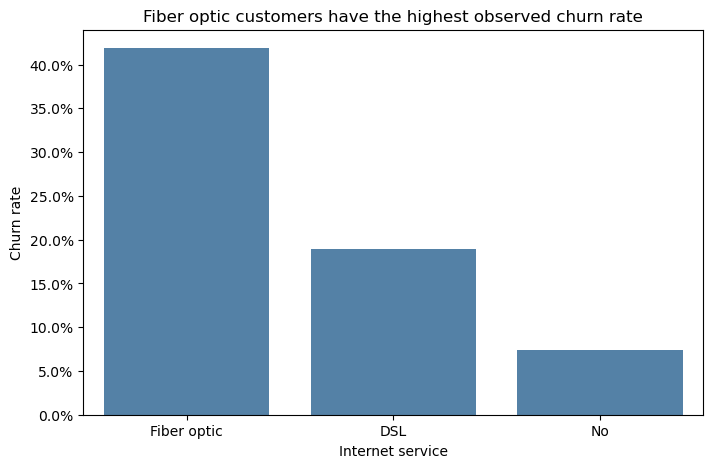

In [7]:
internet_churn = df.groupby("InternetService")["Churn"].apply(lambda values: values.eq("Yes").mean()).sort_values(ascending=False)
display((internet_churn * 100).round(2).rename("churn_rate_pct"))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=internet_churn.index, y=internet_churn.values, color="steelblue", ax=ax)
ax.set(title="Fiber optic customers have the highest observed churn rate", xlabel="Internet service", ylabel="Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

**What we see:** 41.89% of fiber-optic customers churned, compared with 18.96% of DSL customers and 7.40% of customers without internet service.

### Payment method

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: churn_rate_pct, dtype: float64

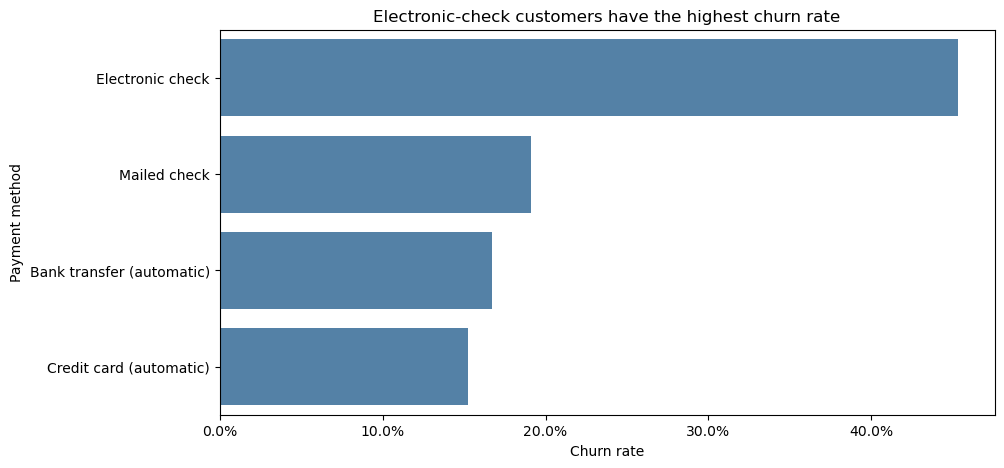

In [8]:
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(lambda values: values.eq("Yes").mean()).sort_values(ascending=False)
display((payment_churn * 100).round(2).rename("churn_rate_pct"))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=payment_churn.values, y=payment_churn.index, color="steelblue", ax=ax)
ax.set(title="Electronic-check customers have the highest churn rate", xlabel="Churn rate", ylabel="Payment method")
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.show()

**What we see:** 45.29% of electronic-check customers churned. Churn rates for the other payment methods were 15.24% to 19.11%.

### Tenure and monthly charges

,tenure,MonthlyCharges
Churn,,
No,38.0,64.425
Yes,10.0,79.650


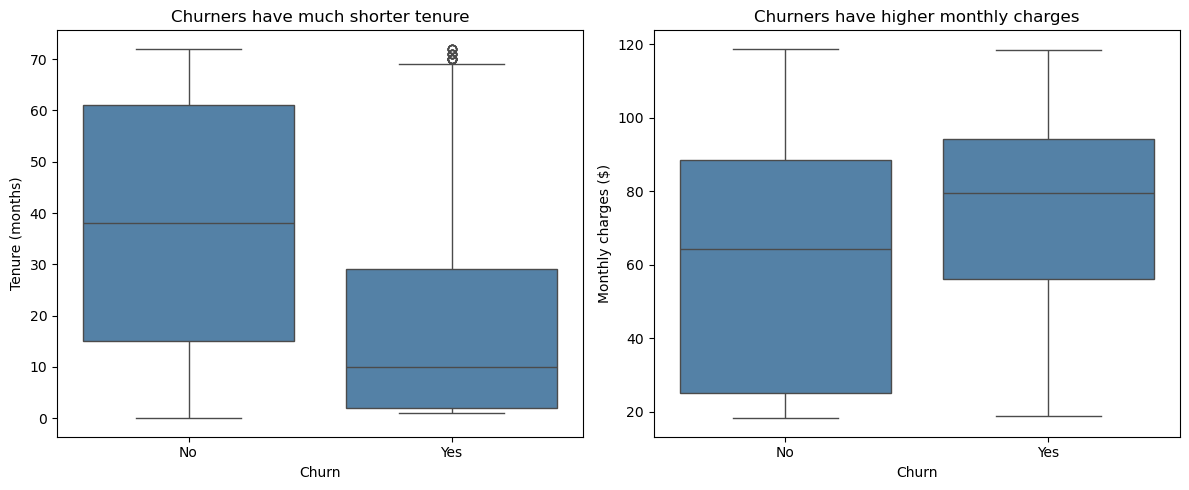

In [9]:
numeric_medians = df.groupby("Churn")[["tenure", "MonthlyCharges"]].median()
display(numeric_medians)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Churn", y="tenure", order=["No", "Yes"], color="steelblue", ax=axes[0])
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No", "Yes"], color="steelblue", ax=axes[1])
axes[0].set(title="Churners have much shorter tenure", xlabel="Churn", ylabel="Tenure (months)")
axes[1].set(title="Churners have higher monthly charges", xlabel="Churn", ylabel="Monthly charges ($)")
plt.tight_layout()
plt.show()

**What we see:** Customers who churned had a middle (median) tenure of 10 months, versus 38 months for those who stayed. Their median monthly charge was $79.65, versus $64.43.

## Statistical tests

The charts show differences; the tests ask whether those differences would be surprising if there were no relationship. A p-value helps answer that question. An effect size tells us how large the relationship is. Neither test proves that one thing causes another.

### Contract type and churn: chi-square test

We use chi-square because both contract type and churn are categories. It compares the number who stayed or left under each contract type. Cramér's V shows the strength of the relationship: 0 means no association, and values closer to 1 mean a stronger association.

In [10]:
from math import sqrt
from scipy.stats import chi2_contingency, mannwhitneyu

contract_table = pd.crosstab(df["Contract"], df["Churn"])
chi2, contract_p, dof, expected = chi2_contingency(contract_table)
assert expected.min() >= 5
n = contract_table.to_numpy().sum()
cramers_v = sqrt(chi2 / (n * min(contract_table.shape[0] - 1, contract_table.shape[1] - 1)))

display(contract_table)
print(f"Chi-square = {chi2:.2f}, df = {dof}, p = {contract_p:.2e}, Cramér's V = {cramers_v:.3f}")
print(f"Smallest expected count = {expected.min():.1f}")

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Chi-square = 1184.60, df = 2, p = 5.86e-258, Cramér's V = 0.410
Smallest expected count = 390.9


**Result:** Contract type and churn are related in this dataset (chi-square = 1184.60, p = 5.86 × 10⁻²⁵⁸; Cramér's V = 0.410). The tiny p-value is strong evidence of a relationship; V = 0.410 shows it is meaningful in size. The chart shows that month-to-month customers churned most. The expected group counts are large enough for this test.

### Monthly charges by churn status: Mann–Whitney U test

Monthly charge is a number, so we compare it between the two churn groups with a Mann–Whitney test. This test ranks charges and asks whether one group tends to have higher values; it does not need charges to follow a normal distribution. Rank-biserial is the effect size: a positive value means churners tend to have higher charges.

In [11]:
churner_charges = df.loc[df["Churn"].eq("Yes"), "MonthlyCharges"]
nonchurner_charges = df.loc[df["Churn"].eq("No"), "MonthlyCharges"]
u_stat, charges_p = mannwhitneyu(churner_charges, nonchurner_charges, alternative="two-sided", method="asymptotic")
rank_biserial = 2 * u_stat / (len(churner_charges) * len(nonchurner_charges)) - 1
median_difference = churner_charges.median() - nonchurner_charges.median()

print(f"Mann–Whitney U = {u_stat:,.1f}, p = {charges_p:.2e}, rank-biserial = {rank_biserial:.3f}")
print(f"Median monthly charge: churners ${churner_charges.median():.3f}; non-churners ${nonchurner_charges.median():.3f}; difference ${median_difference:.3f}")

Mann–Whitney U = 6,003,125.5, p = 3.31e-54, rank-biserial = 0.242
Median monthly charge: churners $79.650; non-churners $64.425; difference $15.225


**Result:** Churners tended to pay more (p = 3.31 × 10⁻⁵⁴; rank-biserial = 0.242). Their median charge was $79.650, versus $64.425 for non-churners: a $15.225 difference. The p-value tests the overall rank difference, not just the median difference.

## Model

We use logistic regression because the outcome is Yes/No and its results can be explained as odds ratios. The model compares customers by contract, tenure, monthly charge, payment method, and senior-citizen status. We leave out `TotalCharges` because it mostly repeats information in tenure and monthly charges. We also left internet service out of the final model: in an earlier version it overlapped strongly with monthly charges (VIFs 13.4 and 7.8). The model describes associations, not causes.

In [12]:
from sklearn.model_selection import train_test_split

features = ["Contract", "tenure", "MonthlyCharges", "PaymentMethod", "SeniorCitizen"]
X = df[features].copy()
y = df["Churn"].eq("Yes").astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)
print(f"Train: {len(X_train):,} rows, {y_train.mean():.2%} churn; test: {len(X_test):,} rows, {y_test.mean():.2%} churn")

Train: 5,634 rows, 26.54% churn; test: 1,409 rows, 26.54% churn


### Encode categories and check collinearity

The model needs numbers, so we turn category labels into yes/no columns. We use two-year contracts and automatic credit-card payments as the comparison groups. The same columns are used for training and testing. VIF checks whether predictors repeat too much of the same information; very high values would make their separate effects hard to trust.

In [13]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

category_levels = {
    "Contract": ["Two year", "One year", "Month-to-month"],
    "PaymentMethod": ["Credit card (automatic)", "Bank transfer (automatic)", "Mailed check", "Electronic check"],
}
for column, levels in category_levels.items():
    X_train[column] = pd.Categorical(X_train[column], categories=levels)
    X_test[column] = pd.Categorical(X_test[column], categories=levels)
    assert X_train[column].notna().all() and X_test[column].notna().all()

X_train_encoded = pd.get_dummies(X_train, drop_first=True, dtype=float)
X_test_encoded = pd.get_dummies(X_test, drop_first=True, dtype=float).reindex(columns=X_train_encoded.columns, fill_value=0)
design_train = sm.add_constant(X_train_encoded)
vif = pd.DataFrame({
    "feature": X_train_encoded.columns,
    "VIF": [variance_inflation_factor(design_train.to_numpy(), i) for i in range(1, design_train.shape[1])],
}).sort_values("VIF", ascending=False)
display(vif)

,feature,VIF
4,Contract_Month-to-month,3.092409
0,tenure,2.363398
7,PaymentMethod_Electronic check,1.975052
6,PaymentMethod_Mailed check,1.819971
3,Contract_One year,1.633787
5,PaymentMethod_Bank transfer (automatic),1.580381
1,MonthlyCharges,1.386812
2,SeniorCitizen,1.086293


### Odds ratios and 95% confidence intervals

An odds ratio compares churn odds between otherwise similar customers. Above 1 means higher odds; below 1 means lower odds. The 95% confidence interval shows a range of plausible values. The table keeps each p-value beside its odds ratio, so the size of the association is visible too.

In [14]:
import numpy as np

inference_model = sm.Logit(y_train, design_train).fit(disp=False)
intervals = inference_model.conf_int()
odds_table = pd.DataFrame({
    "odds_ratio": np.exp(inference_model.params),
    "ci_low": np.exp(intervals[0]),
    "ci_high": np.exp(intervals[1]),
    "p_value": inference_model.pvalues,
}).drop(index="const")
display(odds_table)

,odds_ratio,ci_low,ci_high,p_value
tenure,0.966797,0.962385,0.971230,1.951454e-47
MonthlyCharges,1.025321,1.022081,1.028572,4.492628e-54
SeniorCitizen,1.409685,1.180493,1.683374,1.489136e-04
Contract_One year,2.344187,1.606784,3.420005,9.831645e-06
Contract_Month-to-month,6.162376,4.271528,8.890232,2.359227e-22
PaymentMethod_Bank transfer (automatic),1.019440,0.797032,1.303909,8.781420e-01
PaymentMethod_Mailed check,1.006819,0.787004,1.288030,9.568757e-01
PaymentMethod_Electronic check,1.754358,1.423135,2.162672,1.400140e-07


### Test-set performance and balanced weighting

We hold out 20% of customers to check predictions on data the models did not train on. ROC-AUC shows how well a model ranks churners above non-churners. Recall is the share of actual churners it catches; precision is the share of flagged customers who really churned. The balanced version pays more attention to churners during training. Both versions use a 0.5 cutoff to flag customers.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train_encoded)
train_scaled = scaler.transform(X_train_encoded)
test_scaled = scaler.transform(X_test_encoded)
results = []
for label, weight in [("Standard", None), ("Balanced", "balanced")]:
    model = LogisticRegression(penalty=None, class_weight=weight, max_iter=2000, random_state=RANDOM_SEED)
    model.fit(train_scaled, y_train)
    probability = model.predict_proba(test_scaled)[:, 1]
    predicted = (probability >= 0.5).astype(int)
    results.append({
        "model": label, "ROC_AUC": roc_auc_score(y_test, probability),
        "churn_recall": recall_score(y_test, predicted),
        "churn_precision": precision_score(y_test, predicted),
    })
display(pd.DataFrame(results).set_index("model").round(3))

,ROC_AUC,churn_recall,churn_precision
model,,,
Standard,0.83,0.495,0.607
Balanced,0.83,0.799,0.503


**Three model findings (comparing otherwise similar customers):**

- Month-to-month customers had **6.16 times the churn odds** of two-year customers (95% CI 4.27–8.89). This is about odds, not a 6.16-times higher probability.
- Each extra month of tenure was linked to **lower churn odds**: odds ratio 0.967 (95% CI 0.962–0.971).
- Each extra $1 in monthly charges was linked to **higher churn odds**: odds ratio 1.025 (95% CI 1.022–1.029).

Electronic-check payment was also linked to higher churn odds than automatic credit-card payment (odds ratio 1.75, 95% CI 1.42–2.16). The final VIF values, 1.09–3.09, do not show the large overlap seen in the earlier model.

**On the held-out customers:** Both versions reached ROC-AUC 0.830. The standard model caught 49.5% of churners (recall) and was right about 60.7% of those it flagged (precision). The balanced model caught 79.9% of churners, but was right about 50.3% of those it flagged. This is a trade-off between missing churners and contacting customers who would stay.

## Segments

KMeans puts customers with similar tenure and monthly charges in the same group. We scale those two numbers first so one does not dominate just because it uses larger units. Churn is not used to form the groups; we check each group's churn rate afterward. Segment numbers are names, not risk rankings.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

segment_features = df[["tenure", "MonthlyCharges"]]
scaled_segments = StandardScaler().fit_transform(segment_features)
print("Scaled means:", scaled_segments.mean(axis=0).round(3))
print("Scaled standard deviations:", scaled_segments.std(axis=0).round(3))

segment_models = {}
scores = []
for k in range(3, 7):
    model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(scaled_segments)
    segment_models[k] = model
    score = silhouette_score(scaled_segments, model.labels_, sample_size=2000, random_state=RANDOM_SEED)
    scores.append({"k": k, "silhouette": score})
score_table = pd.DataFrame(scores)
chosen_k = int(score_table.loc[score_table["silhouette"].idxmax(), "k"])
display(score_table.round(3))
print(f"Chosen k: {chosen_k}")

Scaled means: [-0. -0.]
Scaled standard deviations: [1. 1.]


,k,silhouette
0,3,0.449
1,4,0.474
2,5,0.427
3,6,0.415


Chosen k: 4


We try 3, 4, 5, and 6 groups. A silhouette score is higher when customers fit their own group better than other groups. KMeans uses all 7,043 customers; each score checks the same reproducible sample of 2,000 to keep the calculation quick. Four groups scored highest (0.474).

In [17]:
df["segment"] = segment_models[chosen_k].labels_
segment_profile = df.groupby("segment").agg(
    size=("Churn", "size"),
    churn_rate=("Churn", lambda values: values.eq("Yes").mean()),
    mean_tenure=("tenure", "mean"),
    mean_monthly_charge=("MonthlyCharges", "mean"),
)
assert segment_profile["size"].sum() == len(df)
display(segment_profile.round(3))
print(f"Churn-rate spread: {(segment_profile['churn_rate'].max() - segment_profile['churn_rate'].min()):.2%}")

,size,churn_rate,mean_tenure,mean_monthly_charge
segment,,,,
0,1732,0.245,10.488,32.471
1,1952,0.156,58.749,93.020
2,2204,0.492,14.811,81.216
3,1155,0.048,54.115,34.029


Churn-rate spread: 44.42%


**What the four groups look like:**

- **Segment 0:** 1,732 customers; 24.54% churn; mean tenure 10.5 months; mean monthly charge $32.47. Newer, lower-charge customers with moderate churn.
- **Segment 1:** 1,952 customers; 15.63% churn; mean tenure 58.7 months; mean monthly charge $93.02. Long-tenure, higher-charge customers with lower churn.
- **Segment 2:** 2,204 customers; 49.18% churn; mean tenure 14.8 months; mean monthly charge $81.22. Newer, higher-charge customers with the highest observed churn.
- **Segment 3:** 1,155 customers; 4.76% churn; mean tenure 54.1 months; mean monthly charge $34.03. Long-tenure, lower-charge customers with the lowest observed churn.

The groups' churn rates differ by 44.42 percentage points, from 4.76% to 49.18%. This makes them useful for describing customers, but does not show that tenure or price caused churn.

## Impact and recommendations

### Assumptions

- We treat the observed churn rate as a rough guide to **next-month** risk. The dataset does not give us a proven next-month rate. We count only **one month** of charges.
- The counts describe **historical customers**, including some who already churned. For this scenario, we imagine future groups of active customers with the same sizes and average charges. These rows are not a current contact list.
- We assume every customer in those future groups gets one contact. The three target groups do not overlap, so we can add their estimates.
- The low, base, and high churn reductions below are **guesses for planning**, not effects measured by this dataset. A 5-percentage-point reduction would move a 49.18% churn rate to 44.18%; it does not mean a 5% relative reduction.
- **Gross retained charges** = customers contacted × assumed churn reduction × average monthly charge. **Outreach cost** = customers contacted × cost per contact. **Amount after outreach** = gross retained charges − outreach cost. This is not profit: service costs and margins are unknown. No discount is included.

**Action 1 — segment 2:** Send a digital check-in with a link to service help. This group had the highest churn (49.18%). Assume **$1.00 per contact** and **2 / 5 / 8 percentage points** less churn in the low/base/high cases.

**Action 2 — month-to-month customers in segment 0:** Explain longer-contract options without a discount. Month-to-month customers had the highest contract churn (42.71% overall). Assume **$0.50 per contact** and **1 / 3 / 5 percentage points** less churn.

**Action 3 — electronic-check customers in segment 1:** Send a guide to payment options. Electronic-check customers had higher churn in the charts and model. Assume **$0.50 per contact** and **0.5 / 1.5 / 3 percentage points** less churn.

In [18]:
target_masks = {
    "Segment 2: service check-in": df["segment"].eq(2),
    "Segment 0: contract message": df["segment"].eq(0) & df["Contract"].eq("Month-to-month"),
    "Segment 1: payment guide": df["segment"].eq(1) & df["PaymentMethod"].eq("Electronic check"),
}
assert pd.concat(target_masks, axis=1).sum(axis=1).le(1).all()

assumptions = pd.DataFrame({
    "cost_per_contact": [1.00, 0.50, 0.50],
    "low": [0.02, 0.01, 0.005],
    "base": [0.05, 0.03, 0.015],
    "high": [0.08, 0.05, 0.03],
}, index=target_masks.keys())
target_profile = pd.DataFrame({
    name: {
        "customers": int(mask.sum()),
        "observed_churn_rate": df.loc[mask, "Churn"].eq("Yes").mean(),
        "mean_monthly_charge": df.loc[mask, "MonthlyCharges"].mean(),
    }
    for name, mask in target_masks.items()
}).T
display(target_profile.join(assumptions).round(3))

,customers,observed_churn_rate,mean_monthly_charge,cost_per_contact,low,base,high
Segment 2: service check-in,2204.0,0.492,81.216,1.0,0.020,0.050,0.08
Segment 0: contract message,1260.0,0.325,34.766,0.5,0.010,0.030,0.05
Segment 1: payment guide,588.0,0.264,96.474,0.5,0.005,0.015,0.03


In [19]:
impact_rows = []
for target in assumptions.index:
    customers = int(target_profile.loc[target, "customers"])
    charge = target_profile.loc[target, "mean_monthly_charge"]
    cost = customers * assumptions.loc[target, "cost_per_contact"]
    for scenario in ["low", "base", "high"]:
        reduction = assumptions.loc[target, scenario]
        gross = customers * reduction * charge
        impact_rows.append({
            "target": target, "scenario": scenario,
            "reduction_pp": reduction * 100,
            "additional_retained_customers": customers * reduction,
            "gross_monthly_revenue": gross,
            "outreach_cost": cost,
            "net_first_month_after_outreach": gross - cost,
        })
impact_table = pd.DataFrame(impact_rows)
display(impact_table.round(2))
scenario_totals = impact_table.groupby("scenario")[[
    "additional_retained_customers", "gross_monthly_revenue",
    "outreach_cost", "net_first_month_after_outreach",
]].sum().reindex(["low", "base", "high"])
display(scenario_totals.round(2))

,target,scenario,reduction_pp,additional_retained_customers,gross_monthly_revenue,outreach_cost,net_first_month_after_outreach
0,Segment 2: service check-in,low,2.0,44.08,3580.00,2204.0,1376.00
1,Segment 2: service check-in,base,5.0,110.20,8949.99,2204.0,6745.99
2,Segment 2: service check-in,high,8.0,176.32,14319.99,2204.0,12115.99
3,Segment 0: contract message,low,1.0,12.60,438.05,630.0,-191.95
4,Segment 0: contract message,base,3.0,37.80,1314.14,630.0,684.14
5,Segment 0: contract message,high,5.0,63.00,2190.23,630.0,1560.23
6,Segment 1: payment guide,low,0.5,2.94,283.63,294.0,-10.37
7,Segment 1: payment guide,base,1.5,8.82,850.90,294.0,556.90
8,Segment 1: payment guide,high,3.0,17.64,1701.80,294.0,1407.80


,additional_retained_customers,gross_monthly_revenue,outreach_cost,net_first_month_after_outreach
scenario,,,,
low,59.62,4301.68,3128.0,1173.68
base,156.82,11115.03,3128.0,7987.03
high,256.96,18212.02,3128.0,15084.02


### What the assumptions produce

**Worked example — action 1, base case:** 2,204 customers × 5% assumed reduction × the unrounded average monthly charge (about $81.22) = **$8,949.99** in one-month charges kept. Contact costs are 2,204 × $1 = **$2,204.00**. That leaves **$6,745.99 after outreach cost**.

| Recommendation | Customers | Base charges kept | Outreach cost | Base amount after outreach |
| --- | ---: | ---: | ---: | ---: |
| 1. Service check-in: segment 2 | 2,204 | $8,949.99 | $2,204.00 | $6,745.99 |
| 2. Contract message: segment 0 month-to-month | 1,260 | $1,314.14 | $630.00 | $684.14 |
| 3. Payment guide: segment 1 electronic check | 588 | $850.90 | $294.00 | $556.90 |
| **All three** | **4,052** | **$11,115.03** | **$3,128.00** | **$7,987.03** |

With the **low / base / high** assumptions, the combined amount after outreach is **$1,173.68 / $7,987.03 / $15,084.02** for one month. The detailed table above shows each action's range. In the low case, actions 2 and 3 do not cover their contact costs, so pilot them before using them widely. These figures are estimates based on guesses about how well outreach works. A comparison group is needed to measure a real effect. Fractional retained-customer counts in the calculation are averages across possible outcomes, not pieces of a customer.